# CMMS-Based SLA Risk Prediction and Planner Decision Support System

### Project Objective

The objective of this project is to develop a Machine Learning model
that predicts the risk of SLA breach for a new maintenance work request.

The project uses a 3-year CMMS dataset containing approximately 200,000
maintenance work requests.

The model uses information that can be available when a work request is
created, such as:

- Equipment age
- Asset criticality
- Priority
- Emergency status
- Technician availability
- Spare requirement
- PTW requirement
- Department
- Building
- Asset type
- Complaint type
- Maintenance type
- Outside temperature
- SLA response target

The final objective is to support maintenance planners in taking early
action when a work request has a higher risk of SLA breach.

If a request is identified as high risk, the planner can consider:

- Allocating additional technicians
- Checking spare availability
- Escalating the request
- Monitoring the work request closely
- Taking corrective action before the SLA breach happens

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
print("Basic libraries imported successfully")
# Train-test split

from sklearn.model_selection import train_test_split

# Cross validation

from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_score

# Hyperparameter tuning

from sklearn.model_selection import GridSearchCV

# Preprocessing

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder

# Handling missing values

from sklearn.impute import SimpleImputer

# Pipeline

from sklearn.pipeline import Pipeline

# ColumnTransformer

from sklearn.compose import ColumnTransformer

# Classification models

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import BernoulliNB

# Evaluation metrics

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import RocCurveDisplay

# Saving model

import joblib

print("Machine Learning libraries imported successfully")

Basic libraries imported successfully
Machine Learning libraries imported successfully


In [ ]:
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Assignments/Final Capstone Project/CMMS_3Year_Perfect_200k_Dataset.csv")

In [ ]:
df.head()

,WR_ID,Request_Date,Request_Time,Year,Month,Building,Department,Asset_Category,Asset_Type,Equipment_Age,...,Spare_Required,PTW_Required,Outside_Temperature,Response_Target_Min,Actual_Response_Min,Resolution_Time_Hr,Estimated_Cost,Actual_Cost,Customer_Rating,SLA_Met
0,WR0000001,5/10/2025,7:23,2025,5,Building G,Laboratory,ELV,Access Control,6,...,No,No,32,120,189,2.38,2321,2758,3,No
1,WR0000002,12/31/2025,4:40,2025,12,Building A,Kitchen,Plumbing,Pump,19,...,Yes,Yes,16,120,45,0.92,5153,6182,4,Yes
2,WR0000003,11/10/2025,17:11,2025,11,Building D,ICU,Fire,Fire Alarm,8,...,Yes,No,26,120,28,1.47,4181,4673,4,Yes
3,WR0000004,5/2/2023,1:45,2023,5,Building E,Kitchen,Fire,Fire Alarm,23,...,No,No,39,15,5,4.69,5181,5592,5,Yes
4,WR0000005,4/11/2024,3:58,2024,4,Building B,Laundry,Civil,Wall/Paint,8,...,No,Yes,21,30,5,0.56,488,397,4,Yes


In [ ]:
df.shape

(200000, 28)

In [ ]:
df.columns

Index(['WR_ID', 'Request_Date', 'Request_Time', 'Year', 'Month', 'Building',
       'Department', 'Asset_Category', 'Asset_Type', 'Equipment_Age',
       'Criticality', 'Complaint_Type', 'Complaint_Text', 'Maintenance_Type',
       'Priority', 'Emergency', 'Technician_Trade', 'Technician_Count',
       'Spare_Required', 'PTW_Required', 'Outside_Temperature',
       'Response_Target_Min', 'Actual_Response_Min', 'Resolution_Time_Hr',
       'Estimated_Cost', 'Actual_Cost', 'Customer_Rating', 'SLA_Met'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 28 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   WR_ID                200000 non-null  object 
 1   Request_Date         200000 non-null  object 
 2   Request_Time         200000 non-null  object 
 3   Year                 200000 non-null  int64  
 4   Month                200000 non-null  int64  
 5   Building             200000 non-null  object 
 6   Department           200000 non-null  object 
 7   Asset_Category       200000 non-null  object 
 8   Asset_Type           200000 non-null  object 
 9   Equipment_Age        200000 non-null  int64  
 10  Criticality          200000 non-null  object 
 11  Complaint_Type       200000 non-null  object 
 12  Complaint_Text       200000 non-null  object 
 13  Maintenance_Type     200000 non-null  object 
 14  Priority             200000 non-null  object 
 15  Emergency        

In [ ]:
df.describe()

,Year,Month,Equipment_Age,Emergency,Technician_Count,Outside_Temperature,Response_Target_Min,Actual_Response_Min,Resolution_Time_Hr,Estimated_Cost,Actual_Cost,Customer_Rating
count,200000.000000,200000.000000,200000.000000,200000.000000,200000.00000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000
mean,2024.000830,6.519995,12.489670,0.465985,1.74847,29.144225,52.639875,46.965720,5.016481,2829.527370,2886.847535,3.821005
std,0.816457,3.450101,6.918364,0.498843,0.88639,9.676257,38.804935,50.191466,4.523757,1544.605019,1648.607448,1.099164
min,2023.000000,1.000000,1.000000,0.000000,1.00000,15.000000,15.000000,5.000000,0.500000,150.000000,91.000000,1.000000
25%,2023.000000,4.000000,7.000000,0.000000,1.00000,21.000000,30.000000,13.000000,1.800000,1491.000000,1487.000000,3.000000
50%,2024.000000,7.000000,12.500000,0.000000,1.00000,27.000000,30.000000,28.000000,3.630000,2837.000000,2828.000000,4.000000
75%,2025.000000,10.000000,18.000000,1.000000,2.00000,37.000000,60.000000,60.000000,6.760000,4165.000000,4175.000000,5.000000
max,2025.000000,12.000000,24.000000,1.000000,4.00000,48.000000,120.000000,240.000000,73.860000,5499.000000,8734.000000,5.000000


In [ ]:
df.dtypes

,0
WR_ID,object
Request_Date,object
Request_Time,object
Year,int64
Month,int64
Building,object
Department,object
Asset_Category,object
Asset_Type,object
Equipment_Age,int64


In [ ]:
df.isnull().sum()

,0
WR_ID,0
Request_Date,0
Request_Time,0
Year,0
Month,0
Building,0
Department,0
Asset_Category,0
Asset_Type,0
Equipment_Age,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df = df.drop_duplicates()

In [ ]:
# Check number of unique values in every column

unique_values = pd.DataFrame({

    "Column": df.columns,

    "Unique_Values": [
        df[column].nunique()
        for column in df.columns
    ]

})

unique_values

,Column,Unique_Values
0,WR_ID,200000
1,Request_Date,1096
2,Request_Time,1440
3,Year,3
4,Month,12
5,Building,8
6,Department,9
7,Asset_Category,6
8,Asset_Type,15
9,Equipment_Age,24


In [ ]:
#Target Variable
print(df["SLA_Met"].value_counts())

SLA_Met
Yes    130850
No      69150
Name: count, dtype: int64


In [ ]:
#Create ML Target

df["SLA_Breach"] = df["SLA_Met"].map({

    "Yes": 0,

    "No": 1

})
print(df["SLA_Breach"].value_counts())

SLA_Breach
0    130850
1     69150
Name: count, dtype: int64


In [ ]:
#Verify Target Conversion
print("Target mapping:")

print("0 = SLA Met")
print("1 = SLA Breached")

print()

print(
    df["SLA_Breach"].value_counts(
        dropna=False
    )
)

Target mapping:
0 = SLA Met
1 = SLA Breached

SLA_Breach
0    130850
1     69150
Name: count, dtype: int64


In [ ]:
df["SLA_Breach"].isnull().sum()

np.int64(0)

##**Feature Engineering**

In [ ]:
# Convert date safely

request_date_clean = pd.to_datetime(
    df["Request_Date"],
    errors="coerce"
)

# Create date features

df["Request_Year"] = (
    request_date_clean.dt.year
)

df["Request_Month"] = (
    request_date_clean.dt.month
)

df["Request_Day"] = (
    request_date_clean.dt.day
)

df["Request_DayOfWeek"] = (
    request_date_clean.dt.dayofweek
)

# Weekend indicator

df["Request_Weekend"] = (
    df["Request_DayOfWeek"] >= 5
)

In [ ]:
# Convert request time

request_time_clean = pd.to_datetime(
    df["Request_Time"],
    errors="coerce"
)

# Extract hour

df["Request_Hour"] = (
    request_time_clean.dt.hour
)

/tmp/ipykernel_3276/2984149596.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  request_time_clean = pd.to_datetime(


In [ ]:
date_time_columns = [

    "Request_Year",
    "Request_Month",
    "Request_Day",
    "Request_DayOfWeek",
    "Request_Hour"

]

print(
    df[date_time_columns].isnull().sum()
)

Request_Year         0
Request_Month        0
Request_Day          0
Request_DayOfWeek    0
Request_Hour         0
dtype: int64


In [ ]:
#Equipment Age Group
def create_age_group(age):

    if pd.isna(age):

        return "Unknown"

    elif age <= 5:

        return "0-5"

    elif age <= 10:

        return "6-10"

    elif age <= 15:

        return "11-15"

    elif age <= 20:

        return "16-20"

    else:

        return "21+"


df["Equipment_Age_Group"] = (
    df["Equipment_Age"].apply(
        create_age_group
    )
)

SLA_Met          No        Yes
Priority                      
P1        33.932380  66.067620
P2        34.403778  65.596222
P3        34.816200  65.183800
P4        35.292227  64.707773


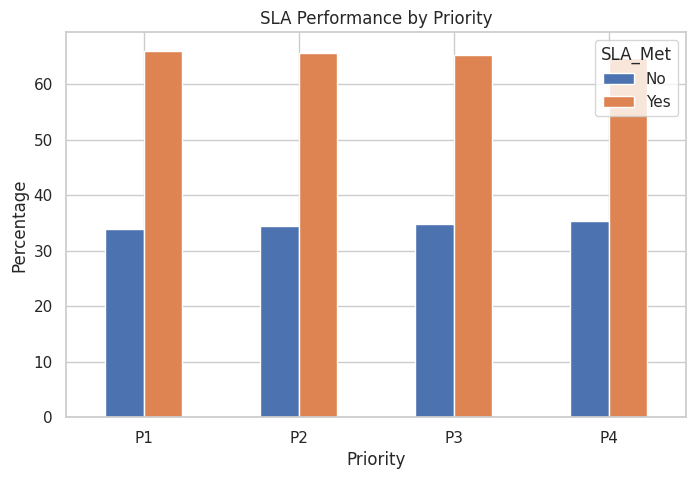

In [ ]:
#EDA: SLA by Priority
priority_sla = pd.crosstab(

    df["Priority"],

    df["SLA_Met"],

    normalize="index"

) * 100

print(priority_sla)

priority_sla.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title(
    "SLA Performance by Priority"
)

plt.xlabel("Priority")
plt.ylabel("Percentage")

plt.xticks(rotation=0)

plt.show()

SLA_Met           No        Yes
Emergency                      
0          34.714381  65.285619
1          34.415271  65.584729


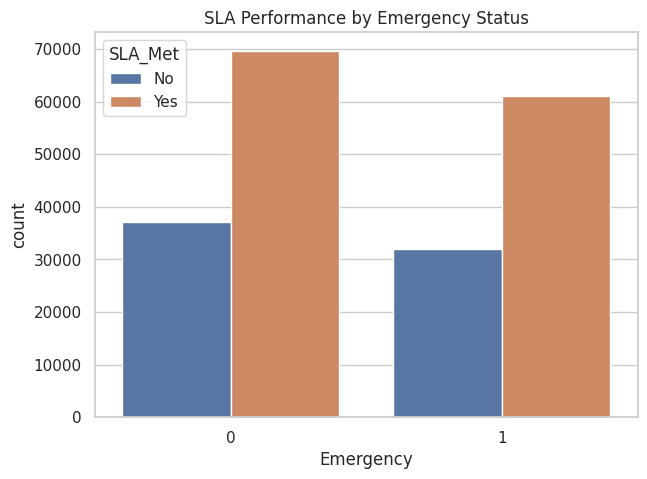

In [ ]:
#SLA by Emergency
emergency_sla = pd.crosstab(

    df["Emergency"],

    df["SLA_Met"],

    normalize="index"

) * 100

print(emergency_sla)
plt.figure(figsize=(7,5))

sns.countplot(

    data=df,

    x="Emergency",

    hue="SLA_Met"

)

plt.title(
    "SLA Performance by Emergency Status"
)

plt.show()

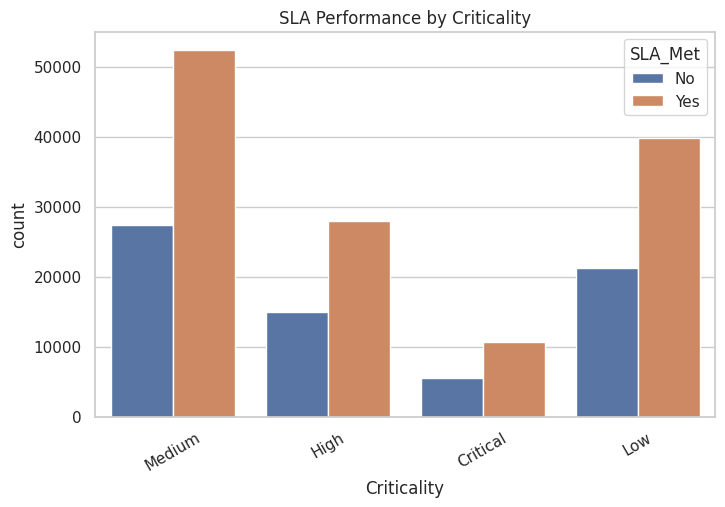

In [ ]:
#SLA by Criticality
plt.figure(figsize=(8,5))

sns.countplot(

    data=df,

    x="Criticality",

    hue="SLA_Met"

)

plt.title(
    "SLA Performance by Criticality"
)

plt.xticks(rotation=30)

plt.show()



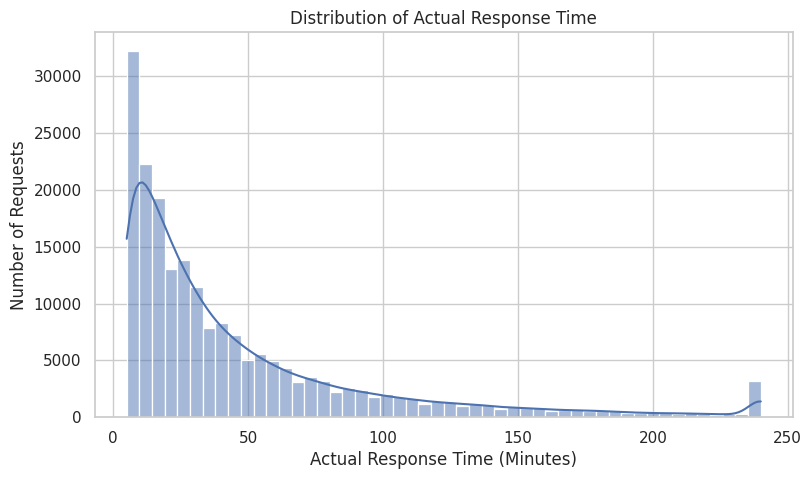

In [ ]:
#Response Time Distribution
plt.figure(figsize=(9,5))

sns.histplot(

    data=df,

    x="Actual_Response_Min",

    bins=50,

    kde=True

)

plt.title(
    "Distribution of Actual Response Time"
)

plt.xlabel(
    "Actual Response Time (Minutes)"
)

plt.ylabel(
    "Number of Requests"
)

plt.show()

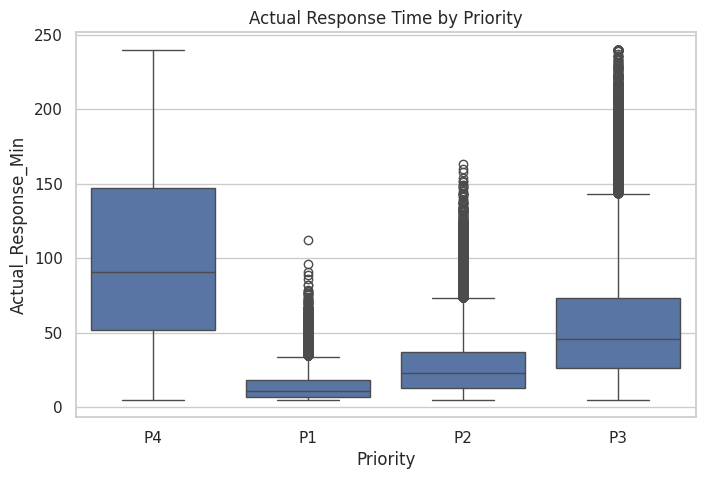

In [ ]:
#Response Time by Priority
plt.figure(figsize=(8,5))

sns.boxplot(

    data=df,

    x="Priority",

    y="Actual_Response_Min"

)

plt.title(
    "Actual Response Time by Priority"
)

plt.show()

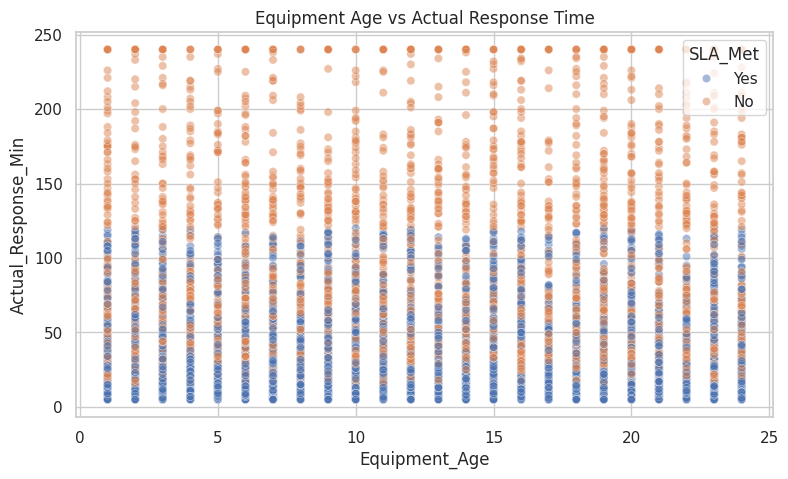

In [ ]:
#Equipment Age vs Response Time
sample_df = df.sample(
    n=10000,
    random_state=42
)

plt.figure(figsize=(9,5))

sns.scatterplot(

    data=sample_df,

    x="Equipment_Age",

    y="Actual_Response_Min",

    hue="SLA_Met",

    alpha=0.5

)

plt.title(
    "Equipment Age vs Actual Response Time"
)

plt.show()

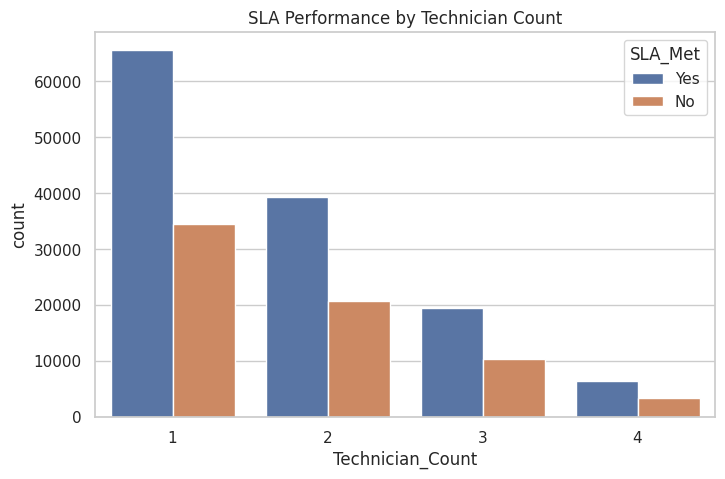

In [ ]:
#Technician Count vs SLA
plt.figure(figsize=(8,5))

sns.countplot(

    data=df,

    x="Technician_Count",

    hue="SLA_Met"

)

plt.title(
    "SLA Performance by Technician Count"
)

plt.show()

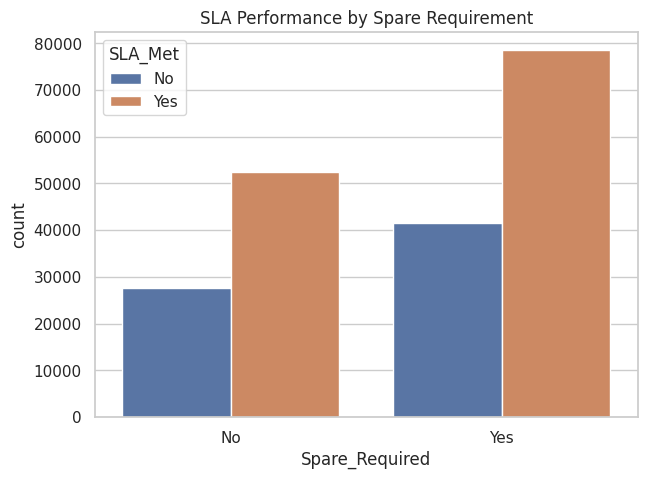

In [ ]:
#Spare Requirement vs SLA

plt.figure(figsize=(7,5))

sns.countplot(

    data=df,

    x="Spare_Required",

    hue="SLA_Met"

)

plt.title(
    "SLA Performance by Spare Requirement"
)

plt.show()

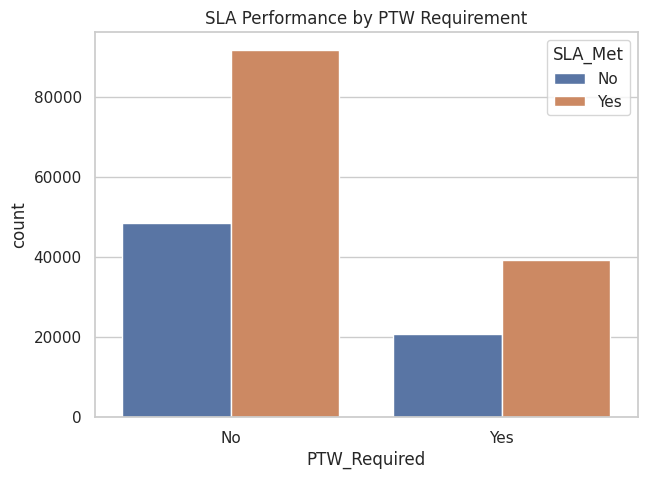

In [ ]:
#PTW Requirement vs SLA
plt.figure(figsize=(7,5))

sns.countplot(

    data=df,

    x="PTW_Required",

    hue="SLA_Met"

)

plt.title(
    "SLA Performance by PTW Requirement"
)

plt.show()

In [ ]:
#SLA by Department
department_sla = pd.crosstab(

    df["Department"],

    df["SLA_Met"],

    normalize="index"

) * 100

department_sla.sort_values(
    "No",
    ascending=False
)

SLA_Met,No,Yes
Department,,
Laundry,34.866382,65.133618
Emergency,34.861306,65.138694
Laboratory,34.855343,65.144657
Pharmacy,34.681974,65.318026
Office,34.536563,65.463437
Kitchen,34.515701,65.484299
Administration,34.506159,65.493841
ICU,34.228040,65.771960
Data Center,34.120589,65.879411


Complaint_Type
Low Pressure                  4260
Water Leakage                 4045
Motor Overheat                3930
Abnormal Noise                3871
Pressure Drop                 3463
Biometric Sensor Error        3441
Break Glass Triggered         3380
Door Magnet Fault             3328
Gate Barrier Stuck            3313
Jockey Pump Continuous Run    3302
Pipe Leakage                  3297
Flow Switch Fault             3280
Card Reader Fault             3269
Control Valve Tamper          3239
Filter Clogged                3195
Name: count, dtype: int64


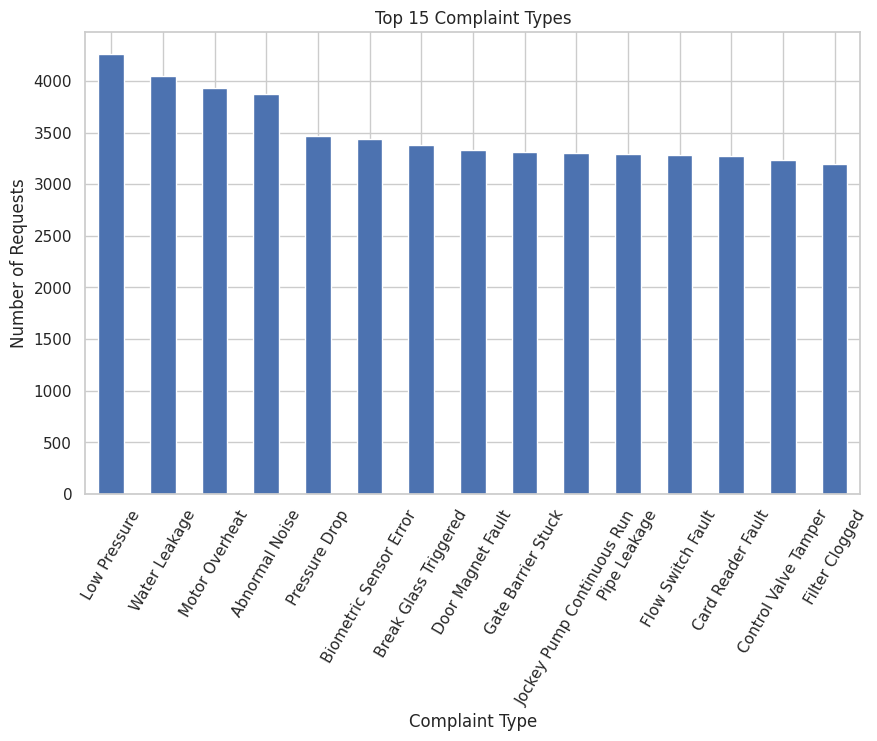

In [ ]:
#Top Complaint Types
top_complaints = (
    df["Complaint_Type"]
    .value_counts()
    .head(15)
)

print(top_complaints)

plt.figure(figsize=(10,6))

top_complaints.plot(
    kind="bar"
)

plt.title(
    "Top 15 Complaint Types"
)

plt.xlabel(
    "Complaint Type"
)

plt.ylabel(
    "Number of Requests"
)

plt.xticks(rotation=60)

plt.show()

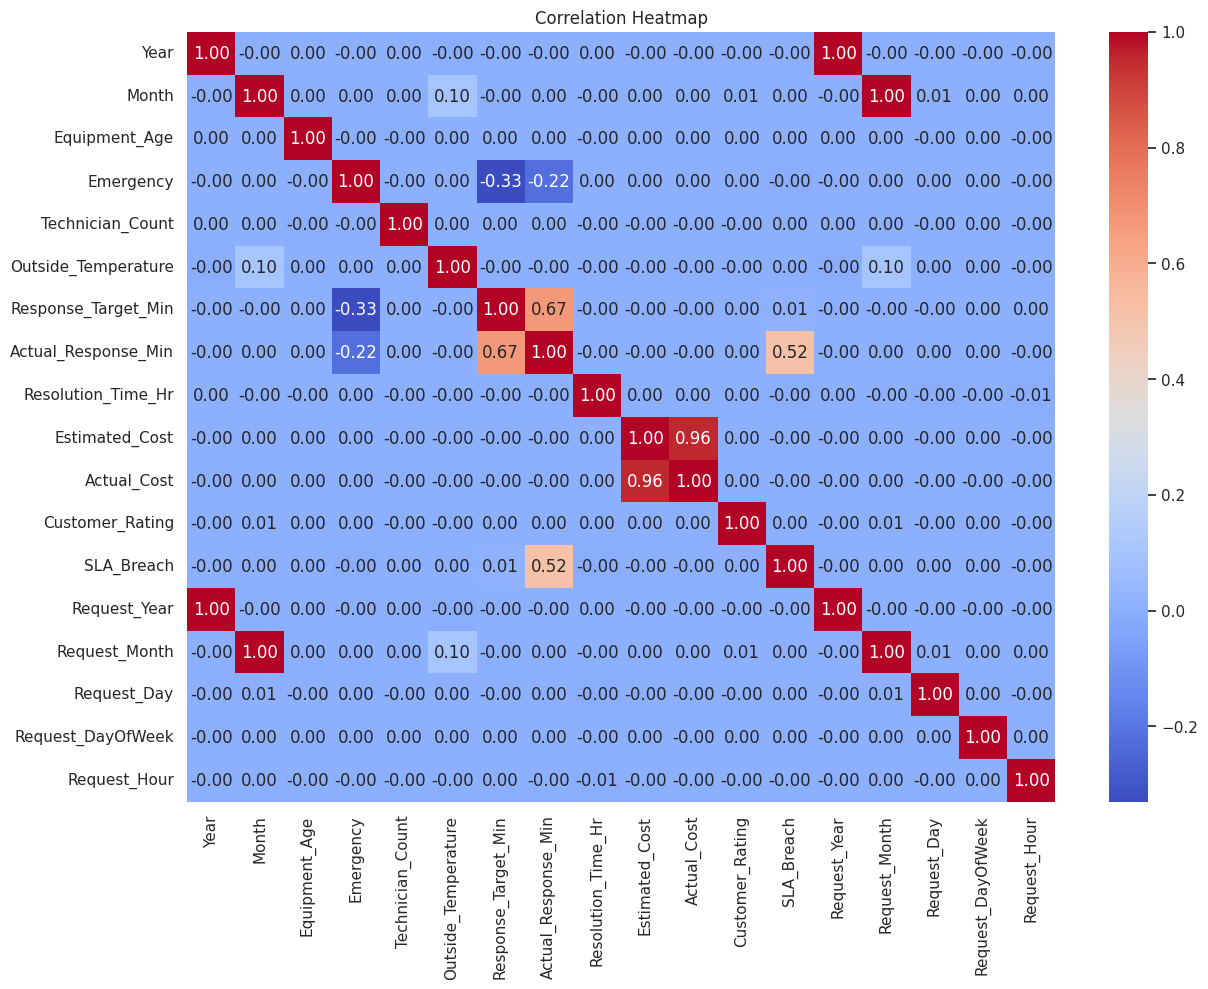

In [ ]:
#Correlation Heatmap
numeric_columns = df.select_dtypes(
    include=np.number
).columns

correlation = df[
    numeric_columns
].corr()

plt.figure(
    figsize=(14,10)
)

sns.heatmap(

    correlation,

    annot=True,

    fmt=".2f",

    cmap="coolwarm"

)

plt.title(
    "Correlation Heatmap"
)

plt.show()

In [ ]:
#Define Features to Remove
columns_to_remove = [

    # Work request identifier
    "WR_ID",

    # Original target
    "SLA_Met",

    # Machine Learning target
    "SLA_Breach",

    # Future / post-event information
    "Actual_Response_Min",
    "Resolution_Time_Hr",
    "Actual_Cost",
    "Customer_Rating",

    # Text is not used in this ML version
    "Complaint_Text",

    # Original date/time columns
    "Request_Date",
    "Request_Time"

]

In [ ]:
#Create X and y
X = df.drop(

    columns=columns_to_remove,

    errors="ignore"

)

y = df["SLA_Breach"]

print(
    "Input data shape:",
    X.shape
)

print(
    "Target data shape:",
    y.shape
)

Input data shape: (200000, 26)
Target data shape: (200000,)


In [ ]:
#Check X for Missing Values
missing_X = X.isnull().sum()

print(
    missing_X[
        missing_X > 0
    ]
)

print()

print(
    "Total missing values in X:",
    X.isnull().sum().sum()
)

Series([], dtype: int64)

Total missing values in X: 0


In [ ]:
#Check Target
print(
    "Missing values in target:",
    y.isnull().sum()
)

print()

print(
    y.value_counts()
)

Missing values in target: 0

SLA_Breach
0    130850
1     69150
Name: count, dtype: int64


In [ ]:
#Identify Numerical and Categorical Features
numeric_features = X.select_dtypes(

    include=[
        "int64",
        "int32",
        "float64",
        "float32"
    ]

).columns.tolist()


categorical_features = X.select_dtypes(

    include=[
        "object",
        "category",
        "bool"
    ]

).columns.tolist()


print("Numerical Features:")
print(numeric_features)

print()

print("Categorical Features:")
print(categorical_features)

Numerical Features:
['Year', 'Month', 'Equipment_Age', 'Emergency', 'Technician_Count', 'Outside_Temperature', 'Response_Target_Min', 'Estimated_Cost', 'Request_Year', 'Request_Month', 'Request_Day', 'Request_DayOfWeek', 'Request_Hour']

Categorical Features:
['Building', 'Department', 'Asset_Category', 'Asset_Type', 'Criticality', 'Complaint_Type', 'Maintenance_Type', 'Priority', 'Technician_Trade', 'Spare_Required', 'PTW_Required', 'Request_Weekend', 'Equipment_Age_Group']


In [ ]:
#Train Test Split
X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.20,

    random_state=42,

    stratify=y

)

print(
    "Training data:",
    X_train.shape
)

print(
    "Testing data:",
    X_test.shape
)

Training data: (160000, 26)
Testing data: (40000, 26)


In [ ]:
#Numerical Preprocessing
numeric_transformer = Pipeline(

    steps=[

        # Fill missing numerical values
        (
            "imputer",

            SimpleImputer(
                strategy="median"
            )
        ),

        # Standardize numerical values
        (
            "scaler",

            StandardScaler()
        )

    ]

)

print(
    "Numerical preprocessing ready")


Numerical preprocessing ready


In [ ]:
#Categorical Preprocessing
categorical_transformer = Pipeline(

    steps=[

        # Fill missing categorical values
        (
            "imputer",

            SimpleImputer(
                strategy="most_frequent"
            )
        ),

        # Convert categories to numerical values
        (
            "onehot",

            OneHotEncoder(

                handle_unknown="ignore",

                sparse_output=True

            )
        )

    ]

)

print(
    "Categorical preprocessing ready"
)

Categorical preprocessing ready


In [ ]:
#Create Preprocessor
preprocessor = ColumnTransformer(

    transformers=[

        (
            "numerical",

            numeric_transformer,

            numeric_features
        ),

        (
            "categorical",

            categorical_transformer,

            categorical_features
        )

    ]

)

print(
    "Complete preprocessing pipeline created"
)

Complete preprocessing pipeline created


In [ ]:
#Logistic Regression
logistic_model = Pipeline(

    steps=[

        (
            "preprocessor",

            preprocessor
        ),

        (
            "classifier",

            LogisticRegression(

                max_iter=1000,

                random_state=42

            )
        )

    ]

)

# Train:
logistic_model.fit(

    X_train,

    y_train

)

print(
    "Logistic Regression trained successfully"
)

Logistic Regression trained successfully


In [ ]:
#Logistic Regression Prediction
y_pred_lr = logistic_model.predict(
    X_test
)

y_prob_lr = logistic_model.predict_proba(
    X_test
)[:, 1]

In [ ]:
#Logistic Regression Evaluation
print("LOGISTIC REGRESSION")
print("-------------------")

print(
    "Accuracy :",
    round(
        accuracy_score(
            y_test,
            y_pred_lr
        ),
        4
    )
)

print(
    "Precision:",
    round(
        precision_score(
            y_test,
            y_pred_lr
        ),
        4
    )
)

print(
    "Recall   :",
    round(
        recall_score(
            y_test,
            y_pred_lr
        ),
        4
    )
)

print(
    "F1 Score :",
    round(
        f1_score(
            y_test,
            y_pred_lr
        ),
        4
    )
)

print(
    "ROC-AUC  :",
    round(
        roc_auc_score(
            y_test,
            y_prob_lr
        ),
        4
    )
)

LOGISTIC REGRESSION
-------------------
Accuracy : 0.6542
Precision: 0.0
Recall   : 0.0
F1 Score : 0.0
ROC-AUC  : 0.5031


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
#Decision Tree
decision_tree_model = Pipeline(

    steps=[

        (
            "preprocessor",

            preprocessor
        ),

        (
            "classifier",

            DecisionTreeClassifier(

                max_depth=8,

                random_state=42,

                class_weight="balanced"

            )
        )

    ]

)

decision_tree_model.fit(

    X_train,

    y_train

)

y_pred_dt = decision_tree_model.predict(
    X_test
)

y_prob_dt = decision_tree_model.predict_proba(
    X_test
)[:, 1]

print(
    "Decision Tree trained successfully"
)

Decision Tree trained successfully


In [ ]:
#Decision Tree Evaluation
print("DECISION TREE")
print("-------------")

print(
    "Accuracy :",
    round(
        accuracy_score(
            y_test,
            y_pred_dt
        ),
        4
    )
)

print(
    "Precision:",
    round(
        precision_score(
            y_test,
            y_pred_dt
        ),
        4
    )
)

print(
    "Recall   :",
    round(
        recall_score(
            y_test,
            y_pred_dt
        ),
        4
    )
)

print(
    "F1 Score :",
    round(
        f1_score(
            y_test,
            y_pred_dt
        ),
        4
    )
)

print(
    "ROC-AUC  :",
    round(
        roc_auc_score(
            y_test,
            y_prob_dt
        ),
        4
    )
)

DECISION TREE
-------------
Accuracy : 0.5353
Precision: 0.3453
Recall   : 0.3839
F1 Score : 0.3636
ROC-AUC  : 0.5007


In [ ]:
#Random Forest
random_forest_model = Pipeline(

    steps=[

        (
            "preprocessor",

            preprocessor
        ),

        (
            "classifier",

            RandomForestClassifier(

                n_estimators=150,

                max_depth=12,

                random_state=42,

                n_jobs=-1,

                class_weight="balanced"

            )
        )

    ]

)

#Train:
random_forest_model.fit(

    X_train,

    y_train

)

y_pred_rf = random_forest_model.predict(
    X_test
)

y_prob_rf = random_forest_model.predict_proba(
    X_test
)[:, 1]

print(
    "Random Forest trained successfully"
)


Random Forest trained successfully


In [ ]:
#Random Forest Evaluation

print("RANDOM FOREST")
print("-------------")

print(
    "Accuracy :",
    round(
        accuracy_score(
            y_test,
            y_pred_rf
        ),
        4
    )
)

print(
    "Precision:",
    round(
        precision_score(
            y_test,
            y_pred_rf
        ),
        4
    )
)

print(
    "Recall   :",
    round(
        recall_score(
            y_test,
            y_pred_rf
        ),
        4
    )
)

print(
    "F1 Score :",
    round(
        f1_score(
            y_test,
            y_pred_rf
        ),
        4
    )
)

print(
    "ROC-AUC  :",
    round(
        roc_auc_score(
            y_test,
            y_prob_rf
        ),
        4
    )
)

RANDOM FOREST
-------------
Accuracy : 0.5561
Precision: 0.3463
Recall   : 0.3199
F1 Score : 0.3326
ROC-AUC  : 0.5007


In [ ]:
#Naive Bayes
naive_bayes_model = Pipeline(

    steps=[

        (
            "preprocessor",

            preprocessor
        ),

        (
            "classifier",

            BernoulliNB()
        )

    ]

)

naive_bayes_model.fit(

    X_train,

    y_train

)

y_pred_nb = naive_bayes_model.predict(
    X_test
)

y_prob_nb = naive_bayes_model.predict_proba(
    X_test
)[:, 1]

print(
    "Naive Bayes trained successfully"
)

Naive Bayes trained successfully


In [ ]:
#Naive Bayes Evaluation
print("NAIVE BAYES")
print("-----------")

print(
    "Accuracy :",
    round(
        accuracy_score(
            y_test,
            y_pred_nb
        ),
        4
    )
)

print(
    "Precision:",
    round(
        precision_score(
            y_test,
            y_pred_nb
        ),
        4
    )
)

print(
    "Recall   :",
    round(
        recall_score(
            y_test,
            y_pred_nb
        ),
        4
    )
)

print(
    "F1 Score :",
    round(
        f1_score(
            y_test,
            y_pred_nb
        ),
        4
    )
)

print(
    "ROC-AUC  :",
    round(
        roc_auc_score(
            y_test,
            y_prob_nb
        ),
        4
    )
)

NAIVE BAYES
-----------
Accuracy : 0.6542
Precision: 0.0
Recall   : 0.0
F1 Score : 0.0
ROC-AUC  : 0.5017


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
#KNN
#KNN is computationally expensive with 200,000 observations, so 30,000-record training sample for this comparison.
knn_sample_size = 30000

X_train_knn, _, y_train_knn, _ = train_test_split(

    X_train,

    y_train,

    train_size=knn_sample_size,

    random_state=42,

    stratify=y_train

)

print(
    "KNN training records:",
    len(X_train_knn)
)

KNN training records: 30000


In [ ]:
knn_model = Pipeline(

    steps=[

        (
            "preprocessor",

            preprocessor
        ),

        (
            "classifier",

            KNeighborsClassifier(

                n_neighbors=5,

                n_jobs=-1

            )
        )

    ]

)

knn_model.fit(

    X_train_knn,

    y_train_knn

)

y_pred_knn = knn_model.predict(
    X_test
)

y_prob_knn = knn_model.predict_proba(
    X_test
)[:, 1]

print(
    "KNN trained successfully"
)

KNN trained successfully


In [ ]:
#KNN Evaluation
print("KNN")
print("---")

print(
    "Accuracy :",
    round(
        accuracy_score(
            y_test,
            y_pred_knn
        ),
        4
    )
)

print(
    "Precision:",
    round(
        precision_score(
            y_test,
            y_pred_knn
        ),
        4
    )
)

print(
    "Recall   :",
    round(
        recall_score(
            y_test,
            y_pred_knn
        ),
        4
    )
)

print(
    "F1 Score :",
    round(
        f1_score(
            y_test,
            y_pred_knn
        ),
        4
    )
)

print(
    "ROC-AUC  :",
    round(
        roc_auc_score(
            y_test,
            y_prob_knn
        ),
        4
    )
)

KNN
---
Accuracy : 0.5811
Precision: 0.3385
Recall   : 0.2215
F1 Score : 0.2678
ROC-AUC  : 0.4975


In [ ]:
#Model Comparison Table
results = pd.DataFrame({

    "Model": [

        "Logistic Regression",

        "Decision Tree",

        "Random Forest",

        "Naive Bayes",

        "KNN"

    ],

    "Accuracy": [

        accuracy_score(
            y_test,
            y_pred_lr
        ),

        accuracy_score(
            y_test,
            y_pred_dt
        ),

        accuracy_score(
            y_test,
            y_pred_rf
        ),

        accuracy_score(
            y_test,
            y_pred_nb
        ),

        accuracy_score(
            y_test,
            y_pred_knn
        )

    ],

    "Precision": [

        precision_score(
            y_test,
            y_pred_lr
        ),

        precision_score(
            y_test,
            y_pred_dt
        ),

        precision_score(
            y_test,
            y_pred_rf
        ),

        precision_score(
            y_test,
            y_pred_nb
        ),

        precision_score(
            y_test,
            y_pred_knn
        )

    ],

    "Recall": [

        recall_score(
            y_test,
            y_pred_lr
        ),

        recall_score(
            y_test,
            y_pred_dt
        ),

        recall_score(
            y_test,
            y_pred_rf
        ),

        recall_score(
            y_test,
            y_pred_nb
        ),

        recall_score(
            y_test,
            y_pred_knn
        )

    ],

    "F1_Score": [

        f1_score(
            y_test,
            y_pred_lr
        ),

        f1_score(
            y_test,
            y_pred_dt
        ),

        f1_score(
            y_test,
            y_pred_rf
        ),

        f1_score(
            y_test,
            y_pred_nb
        ),

        f1_score(
            y_test,
            y_pred_knn
        )

    ],

    "ROC_AUC": [

        roc_auc_score(
            y_test,
            y_prob_lr
        ),

        roc_auc_score(
            y_test,
            y_prob_dt
        ),

        roc_auc_score(
            y_test,
            y_prob_rf
        ),

        roc_auc_score(
            y_test,
            y_prob_nb
        ),

        roc_auc_score(
            y_test,
            y_prob_knn
        )

    ]

})

results = results.sort_values(

    by="F1_Score",

    ascending=False

).reset_index(drop=True)

results

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


,Model,Accuracy,Precision,Recall,F1_Score,ROC_AUC
0,Decision Tree,0.535325,0.345301,0.383876,0.363568,0.500681
1,Random Forest,0.556075,0.346301,0.319884,0.332569,0.500718
2,KNN,0.581125,0.338451,0.221547,0.267797,0.497533
3,Logistic Regression,0.654250,0.000000,0.000000,0.000000,0.503128
4,Naive Bayes,0.654250,0.000000,0.000000,0.000000,0.501687


In [ ]:
#Select Best Model
best_model_name = results.loc[

    0,

    "Model"

]

print(
    "Best model based on F1 Score:"
)

print(
    best_model_name
)

Best model based on F1 Score:
Decision Tree


In [ ]:
#Cross Validation
cv = StratifiedKFold(

    n_splits=5,

    shuffle=True,

    random_state=42

)

In [ ]:
cv_scores = cross_val_score(

    random_forest_model,

    X_train,

    y_train,

    cv=cv,

    scoring="f1",

    n_jobs=-1

)

print(
    "Cross Validation F1 Scores:"
)

for score in cv_scores:

    print(
        round(score, 4)
    )

print()

print(
    "Mean CV F1 Score:",
    round(
        cv_scores.mean(),
        4
    )
)

print(
    "Standard Deviation:",
    round(
        cv_scores.std(),
        4
    )
)

Cross Validation F1 Scores:
0.3284
0.3194
0.3205
0.3193
0.3277

Mean CV F1 Score: 0.3231
Standard Deviation: 0.0041


In [ ]:
#Hyperparameter Tuning
rf_pipeline = Pipeline(

    steps=[

        (
            "preprocessor",

            preprocessor
        ),

        (
            "classifier",

            RandomForestClassifier(

                random_state=42,

                n_jobs=-1,

                class_weight="balanced"

            )
        )

    ]

)

In [ ]:
#Parameter grid:
param_grid = {

    "classifier__n_estimators": [
        100,
        150
    ],

    "classifier__max_depth": [
        8,
        12,
        16
    ],

    "classifier__min_samples_split": [
        2,
        5
    ]

}

In [ ]:
#Grid Search CV
grid_search = GridSearchCV(

    estimator=rf_pipeline,

    param_grid=param_grid,

    cv=3,

    scoring="f1",

    n_jobs=-1,

    verbose=1

)

grid_search.fit(

    X_train,

    y_train

)

print(
    "Hyperparameter tuning completed"
)

Fitting 3 folds for each of 12 candidates, totalling 36 fits
Hyperparameter tuning completed


In [ ]:
#Best Parameters
print(
    "Best Parameters:"
)

print(
    grid_search.best_params_
)

Best Parameters:
{'classifier__max_depth': 8, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 100}


In [ ]:
#Best Cross Validation Score
print(
    "Best Cross Validation F1 Score:"
)

print(
    round(
        grid_search.best_score_,
        4
    )
)

Best Cross Validation F1 Score:
0.3789


In [ ]:
#Final Model
final_model = grid_search.best_estimator_

print(
    "Final model created successfully"
)

Final model created successfully


In [ ]:
#Final Predictions
final_prediction = final_model.predict(
    X_test
)

final_probability = final_model.predict_proba(
    X_test
)[:, 1]

In [ ]:
#Final Model Evaluation
final_accuracy = accuracy_score(

    y_test,

    final_prediction

)

final_precision = precision_score(

    y_test,

    final_prediction

)

final_recall = recall_score(

    y_test,

    final_prediction

)

final_f1 = f1_score(

    y_test,

    final_prediction

)

final_roc_auc = roc_auc_score(

    y_test,

    final_probability

)


print("FINAL MODEL PERFORMANCE")
print("=======================")

print(
    "Accuracy :",
    round(final_accuracy, 4)
)

print(
    "Precision:",
    round(final_precision, 4)
)

print(
    "Recall   :",
    round(final_recall, 4)
)

print(
    "F1 Score :",
    round(final_f1, 4)
)

print(
    "ROC-AUC  :",
    round(final_roc_auc, 4)
)

FINAL MODEL PERFORMANCE
Accuracy : 0.5192
Precision: 0.3433
Recall   : 0.4279
F1 Score : 0.381
ROC-AUC  : 0.4971


In [ ]:
#Final Classification Report
print(
    classification_report(

        y_test,

        final_prediction,

        target_names=[
            "SLA Met",
            "SLA Breached"
        ]

    )
)

              precision    recall  f1-score   support

     SLA Met       0.65      0.57      0.61     26170
SLA Breached       0.34      0.43      0.38     13830

    accuracy                           0.52     40000
   macro avg       0.50      0.50      0.49     40000
weighted avg       0.55      0.52      0.53     40000



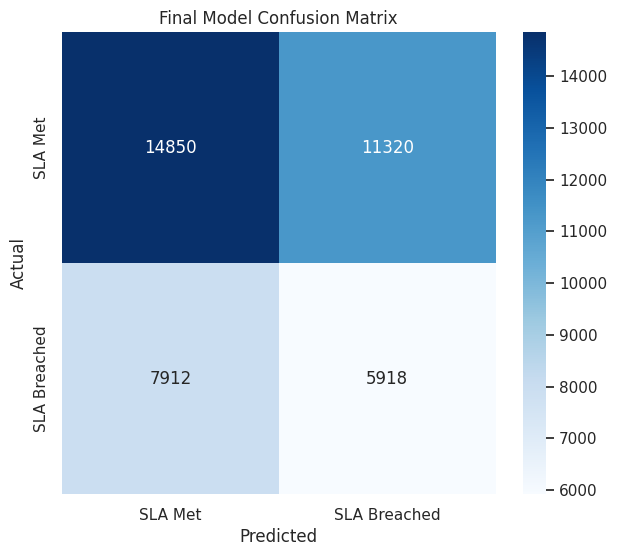

In [ ]:
#Confusion Matrix
cm = confusion_matrix(

    y_test,

    final_prediction

)

plt.figure(
    figsize=(7,6)
)

sns.heatmap(

    cm,

    annot=True,

    fmt="d",

    cmap="Blues",

    xticklabels=[
        "SLA Met",
        "SLA Breached"
    ],

    yticklabels=[
        "SLA Met",
        "SLA Breached"
    ]

)

plt.title(
    "Final Model Confusion Matrix"
)

plt.xlabel(
    "Predicted"
)

plt.ylabel(
    "Actual"
)

plt.show()

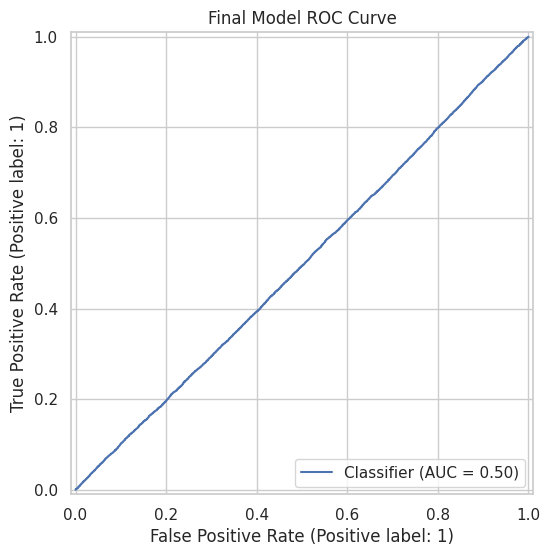

In [ ]:
#ROC Curve
RocCurveDisplay.from_predictions(

    y_test,

    final_probability

)

plt.title(
    "Final Model ROC Curve"
)

plt.show()

In [ ]:
#Feature Importance
# Get preprocessing part

trained_preprocessor = (
    final_model.named_steps[
        "preprocessor"
    ]
)

#Get feature names:
feature_names = (
    trained_preprocessor
    .get_feature_names_out()
)

#Get Random Forest:
final_rf_model = (
    final_model.named_steps[
        "classifier"
    ]
)



In [ ]:
#Feature importance:
feature_importance = pd.DataFrame({

    "Feature": feature_names,

    "Importance":
        final_rf_model.feature_importances_

})

feature_importance = (
    feature_importance
    .sort_values(
        by="Importance",
        ascending=False
    )
)

feature_importance.head(20)

,Feature,Importance
7,numerical__Estimated_Cost,0.082864
5,numerical__Outside_Temperature,0.056592
10,numerical__Request_Day,0.054424
12,numerical__Request_Hour,0.050901
2,numerical__Equipment_Age,0.050378
9,numerical__Request_Month,0.039383
1,numerical__Month,0.037448
11,numerical__Request_DayOfWeek,0.033986
6,numerical__Response_Target_Min,0.024046
4,numerical__Technician_Count,0.021418


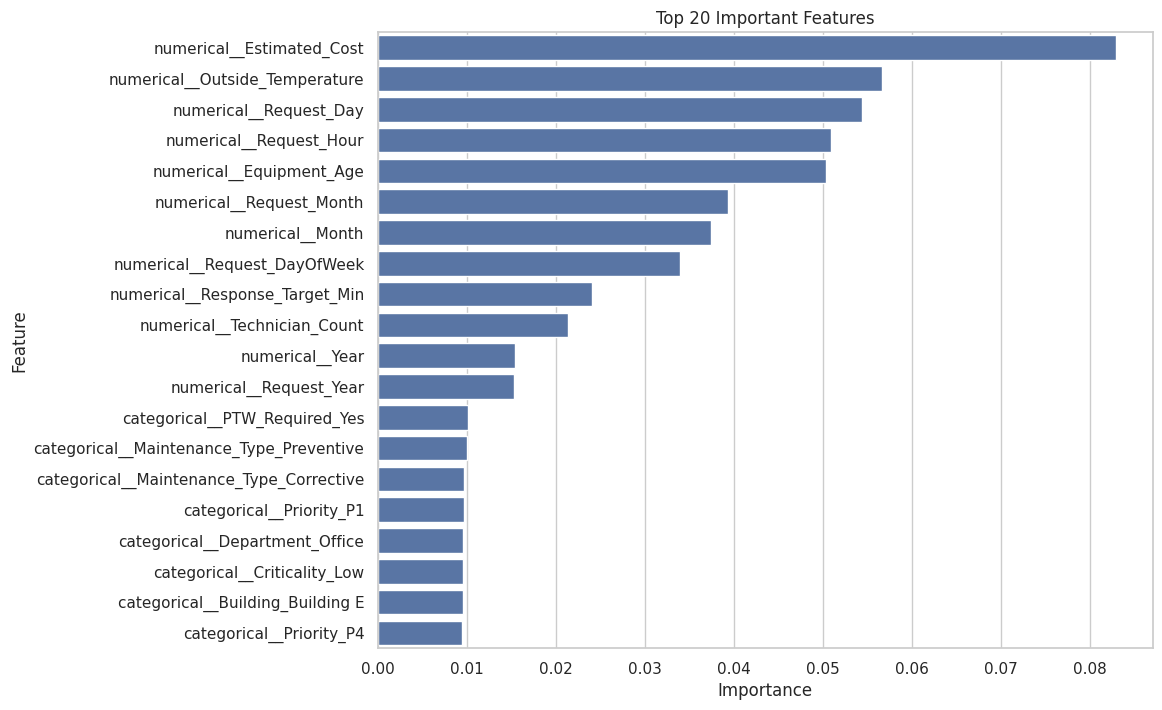

In [ ]:
#Feature Importance Chart
top_features = (
    feature_importance
    .head(20)
)

plt.figure(
    figsize=(10,8)
)

sns.barplot(

    data=top_features,

    x="Importance",

    y="Feature"

)

plt.title(
    "Top 20 Important Features"
)

plt.xlabel(
    "Importance"
)

plt.ylabel(
    "Feature"
)

plt.show()

In [ ]:
#Manual Testing
print(
    "Model input columns:"
)

print(
    X.columns.tolist()
)

Model input columns:
['Year', 'Month', 'Building', 'Department', 'Asset_Category', 'Asset_Type', 'Equipment_Age', 'Criticality', 'Complaint_Type', 'Maintenance_Type', 'Priority', 'Emergency', 'Technician_Trade', 'Technician_Count', 'Spare_Required', 'PTW_Required', 'Outside_Temperature', 'Response_Target_Min', 'Estimated_Cost', 'Request_Year', 'Request_Month', 'Request_Day', 'Request_DayOfWeek', 'Request_Weekend', 'Request_Hour', 'Equipment_Age_Group']


In [ ]:
#Create a Test Work Request

new_request = pd.DataFrame({

    "Year": [2026],

    "Month": [8],

    "Building": ["Building A"],

    "Department": ["HVAC"],

    "Asset_Category": ["HVAC"],

    "Asset_Type": ["AHU"],

    "Equipment_Age": [15],

    "Criticality": ["High"],

    "Complaint_Type": ["Cooling Issue"],

    "Maintenance_Type": ["Corrective"],

    "Priority": ["P2"],

    "Emergency": [1],

    "Technician_Trade": [
        "HVAC Technician"
    ],

    "Technician_Count": [1],

    "Spare_Required": ["Yes"],

    "PTW_Required": ["No"],

    "Outside_Temperature": [34],

    "Response_Target_Min": [30],

    "Estimated_Cost": [500],

    "Request_Year": [2026],

    "Request_Month": [8],

    "Request_Day": [20],

    "Request_DayOfWeek": [3],

    "Request_Weekend": [0],

    "Request_Hour": [10],

    "Equipment_Age_Group": ["11-15"]

})

In [ ]:
#Verify Manual Test Columns
print(
    "Missing columns required by model:"
)

missing_columns = set(
    X.columns
) - set(
    new_request.columns
)

print(
    missing_columns
)

Missing columns required by model:
set()


In [ ]:
#print(
    "Extra columns:"
)

extra_columns = set(
    new_request.columns
) - set(
    X.columns
)

print(
    extra_columns
)

IndentationError: unexpected indent (3569262435.py, line 2)

In [ ]:
set()

set()

In [ ]:
#Arrange Columns Correctly

new_request = new_request[
    X.columns
]

print(
    "Manual test input is ready"
)

Manual test input is ready


In [ ]:
#Manual Prediction
prediction = final_model.predict(

    new_request

)

probability = final_model.predict_proba(

    new_request

)[0][1]


print(
    "Predicted Class:",
    prediction[0]
)

print(
    "SLA Breach Probability:",
    round(
        probability * 100,
        2
    ),
    "%"
)

Predicted Class: 0
SLA Breach Probability: 49.93 %


In [ ]:
#Planner Risk Classification
if probability >= 0.70:

    risk_level = "HIGH"

elif probability >= 0.40:

    risk_level = "MEDIUM"

else:

    risk_level = "LOW"


print(
    "Risk Level:",
    risk_level
)

Risk Level: MEDIUM


In [ ]:
#Planner Recommendation
if risk_level == "HIGH":

    recommendation = """

1. Allocate additional technician if available.
2. Check spare availability immediately.
3. Escalate the work request if required.
4. Closely monitor response time.
5. Inform the responsible supervisor/planner.

"""

elif risk_level == "MEDIUM":

    recommendation = """

1. Monitor the work request closely.
2. Confirm technician availability.
3. Check spare requirements.
4. Follow up before the SLA target approaches.

"""

else:

    recommendation = """

1. Continue normal planning.
2. Monitor the work request according to standard procedure.
3. No additional intervention is required at this stage.

"""


print(
    "Recommended Planner Action:"
)

print(
    recommendation
)

Recommended Planner Action:


1. Monitor the work request closely.
2. Confirm technician availability.
3. Check spare requirements.
4. Follow up before the SLA target approaches.




In [ ]:
#Final Planner Output
print("=" * 50)

print(
    "       CMMS SLA RISK PREDICTION"
)

print("=" * 50)

print()

print(
    "SLA Breach Probability:",
    round(
        probability * 100,
        2
    ),
    "%"
)

print(
    "Risk Level:",
    risk_level
)

print(
    "Prediction:",
    "SLA Breach"
    if prediction[0] == 1
    else "SLA Met"
)

print()

print(
    "Recommended Action:"
)

print(
    recommendation
)

print("=" * 50)

       CMMS SLA RISK PREDICTION

SLA Breach Probability: 49.93 %
Risk Level: MEDIUM
Prediction: SLA Met

Recommended Action:


1. Monitor the work request closely.
2. Confirm technician availability.
3. Check spare requirements.
4. Follow up before the SLA target approaches.




In [ ]:
#Test Multiple Requests
test_requests = pd.DataFrame({

    "Year": [2026, 2026, 2026],

    "Month": [8, 8, 8],

    "Building": [
        "Building A",
        "Building B",
        "Building C"
    ],

    "Department": [
        "HVAC",
        "Electrical",
        "Plumbing"
    ],

    "Asset_Category": [
        "HVAC",
        "Electrical",
        "Plumbing"
    ],

    "Asset_Type": [
        "AHU",
        "Electrical Panel",
        "Pump"
    ],

    "Equipment_Age": [
        15,
        5,
        20
    ],

    "Criticality": [
        "High",
        "Medium",
        "High"
    ],

    "Complaint_Type": [
        "Cooling Issue",
        "Power Issue",
        "Water Leakage"
    ],

    "Maintenance_Type": [
        "Corrective",
        "Corrective",
        "Corrective"
    ],

    "Priority": [
        "P2",
        "P3",
        "P1"
    ],

    "Emergency": [
        1,
        0,
        1
    ],

    "Technician_Trade": [
        "HVAC Technician",
        "Electrical Technician",
        "Plumber"
    ],

    "Technician_Count": [
        1,
        2,
        1
    ],

    "Spare_Required": [
        "Yes",
        "No",
        "Yes"
    ],

    "PTW_Required": [
        "No",
        "Yes",
        "No"
    ],

    "Outside_Temperature": [
        34,
        30,
        32
    ],

    "Response_Target_Min": [
        30,
        60,
        15
    ],

    "Estimated_Cost": [
        500,
        300,
        1000
    ],

    "Request_Year": [
        2026,
        2026,
        2026
    ],

    "Request_Month": [
        8,
        8,
        8
    ],

    "Request_Day": [
        20,
        20,
        20
    ],

    "Request_DayOfWeek": [
        3,
        3,
        3
    ],

    "Request_Weekend": [
        0,
        0,
        0
    ],

    "Request_Hour": [
        10,
        14,
        18
    ],

    "Equipment_Age_Group": [
        "11-15",
        "0-5",
        "16-20"
    ]

})

In [ ]:
#Multiple Predictions
test_requests = test_requests[
    X.columns
]

test_predictions = (
    final_model.predict(
        test_requests
    )
)

test_probabilities = (
    final_model.predict_proba(
        test_requests
    )[:, 1]
)

In [ ]:
#Create Planner Results
manual_results = pd.DataFrame({

    "Priority":
        test_requests["Priority"],

    "Emergency":
        test_requests["Emergency"],

    "Equipment_Age":
        test_requests["Equipment_Age"],

    "Technician_Count":
        test_requests["Technician_Count"],

    "Breach_Probability":
        test_probabilities,

    "Risk_Percentage":
        test_probabilities * 100,

    "Prediction":
        np.where(
            test_predictions == 1,
            "SLA Breach",
            "SLA Met"
        )

})

manual_results

,Priority,Emergency,Equipment_Age,Technician_Count,Breach_Probability,Risk_Percentage,Prediction
0,P2,1,15,1,0.499294,49.929378,SLA Met
1,P3,0,5,2,0.502225,50.222508,SLA Breach
2,P1,1,20,1,0.500444,50.044360,SLA Breach


In [ ]:
#Risk Level for Multiple Tickets
def classify_risk(probability):

    if probability >= 0.70:

        return "HIGH"

    elif probability >= 0.40:

        return "MEDIUM"

    else:

        return "LOW"


manual_results["Risk_Level"] = (

    manual_results[
        "Breach_Probability"
    ].apply(
        classify_risk
    )

)

manual_results

,Priority,Emergency,Equipment_Age,Technician_Count,Breach_Probability,Risk_Percentage,Prediction,Risk_Level
0,P2,1,15,1,0.499294,49.929378,SLA Met,MEDIUM
1,P3,0,5,2,0.502225,50.222508,SLA Breach,MEDIUM
2,P1,1,20,1,0.500444,50.044360,SLA Breach,MEDIUM


In [ ]:
#Save Final Model
joblib.dump(

    final_model,

    "cmms_sla_risk_model.pkl"

)

print(
    "Final model saved successfully"
)

Final model saved successfully


In [ ]:
#Save Model Input Columns
model_columns = X.columns.tolist()

joblib.dump(

    model_columns,

    "cmms_model_columns.pkl"

)

print(
    "Model column information saved"
)

Model column information saved


In [ ]:
#Download Model
from google.colab import files

files.download(
    "cmms_sla_risk_model.pkl"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
#Download Model Columns
files.download(
    "cmms_model_columns.pkl"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
#Save Model Results
results.to_csv(
    "CMMS_Model_Comparison.csv",
    index=False
)

print(
    "Model comparison saved"
)

Model comparison saved


In [ ]:
#Download Results
files.download(
    "CMMS_Model_Comparison.csv"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Project Conclusion

In this project, a Machine Learning based CMMS SLA Risk Prediction System
was developed using a 3-year dataset containing approximately 200,000
maintenance work requests.

The project followed the complete Machine Learning workflow:

1. Business problem identification
2. Data loading
3. Data understanding
4. Data quality checking
5. Exploratory Data Analysis
6. Feature engineering
7. Data preprocessing
8. Handling missing values
9. Categorical encoding
10. Feature scaling
11. Train-test splitting
12. Classification model development
13. Model comparison
14. Cross-validation
15. Hyperparameter tuning
16. Final model selection
17. Model evaluation
18. Manual testing
19. Model saving

The final model can be used as the Machine Learning component of a
Planner Decision Support System.

The purpose of the system is not to replace the maintenance planner.
Instead, it provides an early warning so that planners can take
appropriate action before a potential SLA breach occurs.